In [16]:
def makeFullAdder():
    from qiskit import QuantumCircuit
    # from qiskit.primitives import StatevectorSampler
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    sampler = StatevectorSampler()

        
    #since these operations are from right to left, we iterate backwards:
        
    # cr = ClassicalRegister(5,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    qr2 = QuantumRegister(1,"A")
    qr3 = QuantumRegister(1,"B")
    qr4 = QuantumRegister(1,"Carry_in")
    qr5 = QuantumRegister(1,"Carry_out")
    qr6 = QuantumRegister(1,"Sum")
    qr7 = QuantumRegister(1,"Temp1")
    qr8 = QuantumRegister(1,"Temp2")
    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, name='Full-adder circuit')

    control_1 = 0
    control_2 = 1
    A = 2
    B = 3
    Carry_in = 4
    Carry_out = 5
    Sum = 6
    Temp1 = 7
    Temp2 = 8


    #set up the SUM of the LSBs (least signigicant bits)
    #First XOR (sum):
    #XOR A4 and B4 to fill T1
    qc.append(CCXGate(), [control_2,A,Temp1])
    qc.append(CCXGate(), [control_2,B,Temp1])

    #Perform XOR between the T1 and the carry to get the sum
        #Xor with T1
    qc.append(CCXGate(), [control_2,Temp1,Sum])

        #Xor with carry ****
    qc.append(CCXGate(), [control_2,Carry_in,Sum])

    #Sum between A4 and B4 is done



    #Carry for A4 and B4
        #AND between T1 and C-IN dumped into T2 ****
    qc.append(CCXGate(),[Carry_in,Temp1,Temp2])


        #now we clean T1 from the A4 XOR B4 operation
    qc.append(CCXGate(), [control_2,B,Temp1])
    qc.append(CCXGate(), [control_2,A,Temp1])

        #AND between A4 and B4 into T1
    qc.append(CCXGate(),[A,B,Temp1])

    #OR T1 and T2:
        #First, Not(T2)
    qc.append(CCXGate(), [control_1,control_2,Temp2])
        #Second, Not(T1)
    qc.append(CCXGate(), [control_1, control_2, Temp1])
    #And both T1 and T2 into carry bit 2 
    qc.append(CCXGate(), [Temp1, Temp2, Carry_out])
    #Finally, invert carry bit
    qc.append(CCXGate(), [control_1, control_2, Carry_out])

    #Or finished and Carry computed, clean T1 and T2
    # Since T2 was calculated using T1, we are going to have to rebuild that sucker back to the state it held before T2 was filled 

    #reverse the NOT and AND
        #the NOT
    qc.append(CCXGate(), [control_1, control_2, Temp1])

        #the and
    qc.append(CCXGate(), [A, B, Temp1])

    #T1 should be back into its OG state, so now we recompute A XOR B
    qc.append(CCXGate(), [control_2,A,Temp1])
    qc.append(CCXGate(), [control_2,B,Temp1])

    #undo NOT T2
    qc.append(CCXGate(), [control_1,control_2,Temp2])

    #UNDO T1 AND C_In
    qc.append(CCXGate(),[Carry_in,Temp1,Temp2])

    #T2 is now back to its og state, now clean T1 again
    qc.append(CCXGate(), [control_2,B,Temp1])
    qc.append(CCXGate(), [control_2,A,Temp1])

    adder_qc = qc.to_gate(label="Full adder")
    return adder_qc

    #Now repeat for all qbits


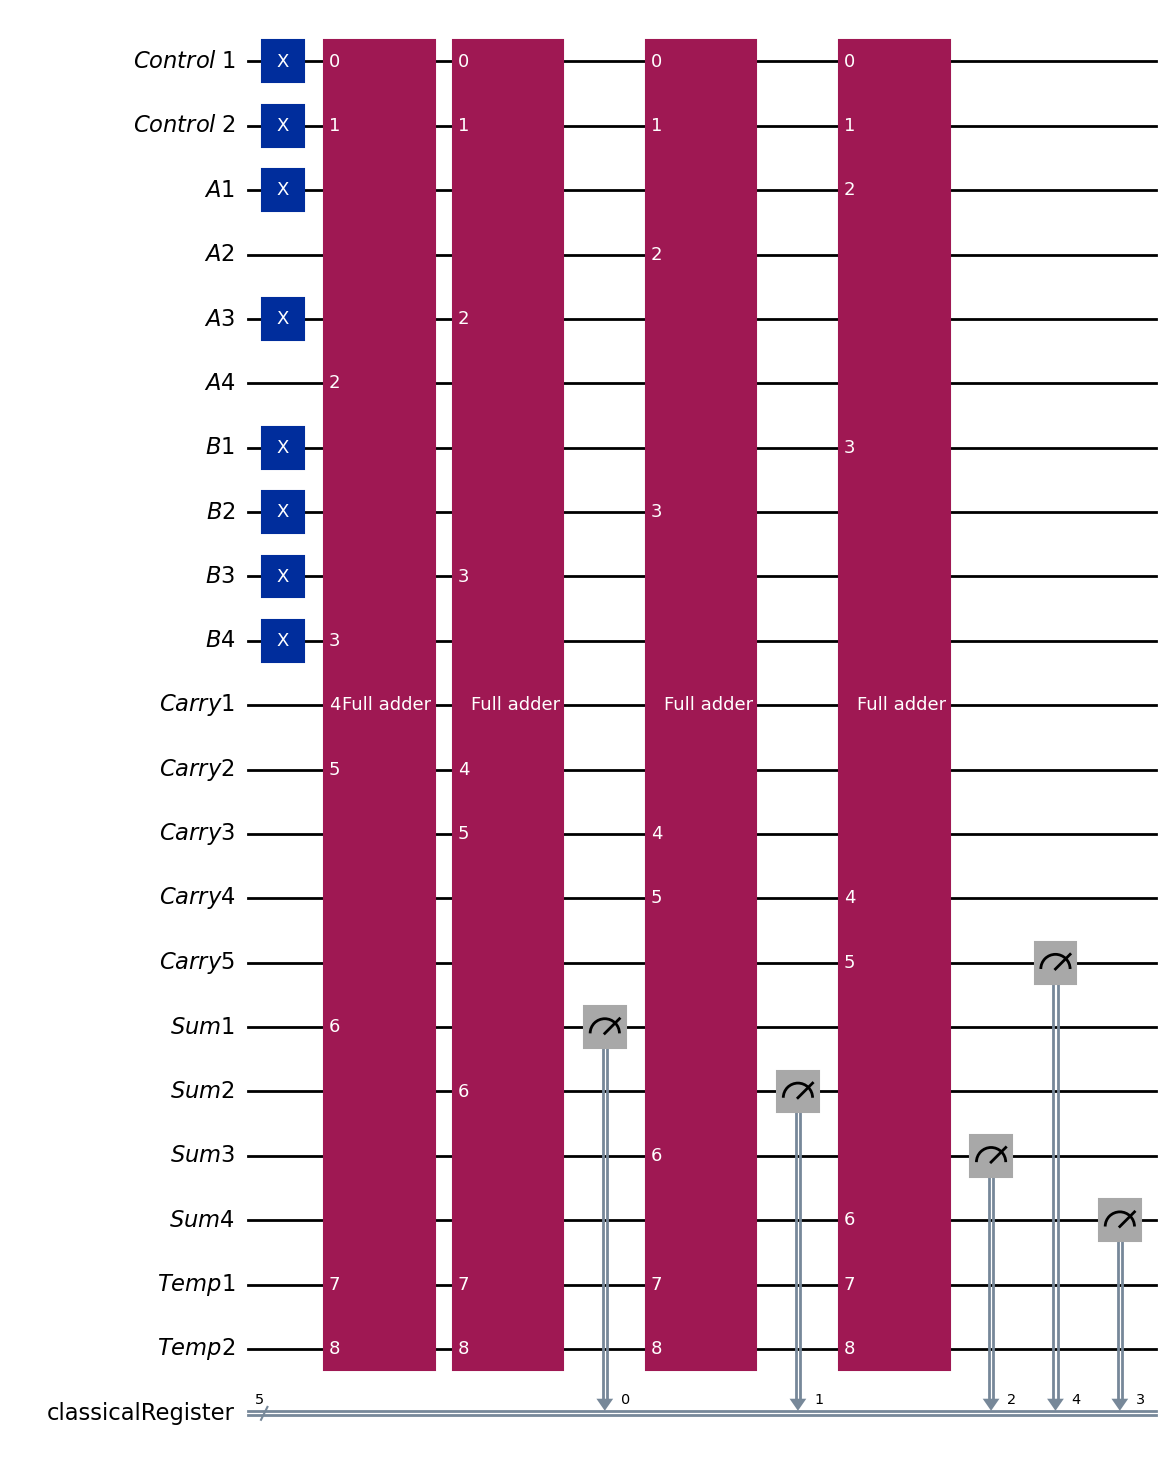

11001 → carry = 1 sum bits = 1001 Result = 25


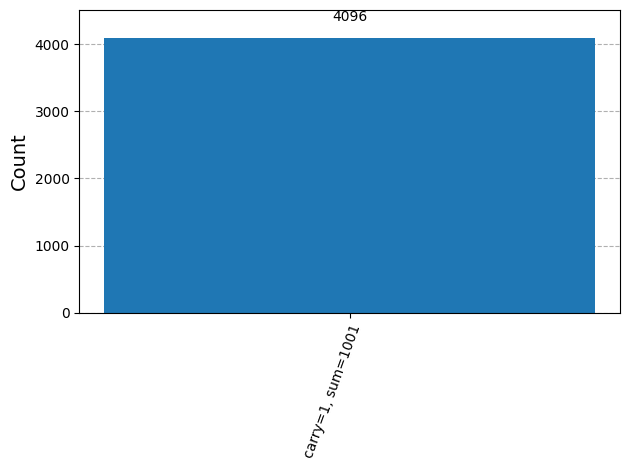

In [20]:
def FourBitQuantumAdder(number1 = None, number2 = None):

    from qiskit import QuantumCircuit
    # from qiskit.primitives import StatevectorSampler
    from qiskit.circuit import QuantumRegister, ClassicalRegister
    from qiskit.visualization import plot_histogram
    from qiskit.circuit.library import CCXGate, XGate, HGate, Reset, swap
    from qiskit.primitives import StatevectorSampler
    from IPython.display import display
    sampler = StatevectorSampler()

        
        #since these operations are from right to left, we iterate backwards:
        
    cr = ClassicalRegister(5,"classicalRegister")
    qr0 = QuantumRegister(1,"Control 1")
    qr1 = QuantumRegister(1,"Control 2")
    qr2 = QuantumRegister(1,"A1")
    qr3 = QuantumRegister(1,"A2")
    qr4 = QuantumRegister(1,"A3")
    qr5 = QuantumRegister(1,"A4")

    qr6 = QuantumRegister(1,"B1")
    qr7 = QuantumRegister(1,"B2")
    qr8 = QuantumRegister(1,"B3")
    qr9 = QuantumRegister(1,"B4")
    qr10 = QuantumRegister(1,"Carry1")
    qr11 = QuantumRegister(1,"Carry2")
    qr12 = QuantumRegister(1,"Carry3")
    qr13 = QuantumRegister(1,"Carry4")
    qr14 = QuantumRegister(1,"Carry5")
    qr15 = QuantumRegister(1,"Sum1")
    qr16 = QuantumRegister(1,"Sum2")
    qr17 = QuantumRegister(1,"Sum3")
    qr18 = QuantumRegister(1,"Sum4")
    qr19 = QuantumRegister(1,"Temp1")
    qr20 = QuantumRegister(1,"Temp2")
    qc = QuantumCircuit(qr0, qr1, qr2, qr3, qr4, qr5, qr6, qr7, qr8, qr9, qr10, qr11, qr12, qr13, qr14, qr15, qr16, qr17, qr18, qr19, qr20, cr, name='Full-adder circuit')

    control_1 = 0
    control_2 = 1
    A1 = 2
    A2 = 3
    A3 = 4
    A4 = 5
    B1 = 6
    B2 = 7
    B3 = 8
    B4 = 9
    Carry1 = 10
    Carry2 = 11
    Carry3 = 12
    Carry4 = 13
    Carry5 = 14
    Sum1 = 15
    Sum2 = 16
    Sum3 = 17
    Sum4 = 18
    Temp1 = 19
    Temp2 = 20

    if(number1 != None and number2 != None):
        if((number1 < 0 or number1 > 15 or number2 < 0 or number2 > 15)):
            print("Input Error. Inputs must be greater than or equal to 0 and less than or equal to 15")
            return False
        binary1 = bin(number1)[2:]
        binary2 = bin(number2)[2:]
        count = 2
        if(len(binary1) != 4):
            length = 4 - len(binary1)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary1 = buff + binary1
        if(len(binary2) != 4):
            length = 4 - len(binary2)
            buff = ""
            for x in range(0, (length)):
                buff += "0"
            binary2 = buff + binary2
        # print(f"first operand {binary1} and second operand {binary2}\n")


    
    #read the input and set the 
    #appropiate qbits to |1>

        for x in range(0,4):
            if(binary1[x] == "1"):
                qc.append(XGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            if(binary2[x] == "1"):
                qc.append(XGate(), [count])
            count += 1
    else:
        count = 2
        for x in range(0,4):
            qc.append(HGate(), [count])
            count += 1

        count = 6
        for x in range(0,4):
            qc.append(HGate(), [count])
            count += 1





    #set the control bit to |1>
    qc.append(XGate(), [control_1])
    qc.append(XGate(), [control_2])

    full_adder = makeFullAdder()
    qc.append(full_adder, [control_1, control_2, A4, B4, Carry1, Carry2, Sum1, Temp1, Temp2 ])
    qc.append(full_adder, [control_1, control_2, A3, B3, Carry2, Carry3, Sum2, Temp1, Temp2 ])
    qc.append(full_adder, [control_1, control_2, A2, B2, Carry3, Carry4, Sum3, Temp1, Temp2 ])
    qc.append(full_adder, [control_1, control_2, A1, B1, Carry4, Carry5, Sum4, Temp1, Temp2 ])


    # #now we can meassure carry and Sum
    #carry
    qc.measure(Carry5,4)
    #and sum
    qc.measure(Sum4, 3)
    qc.measure(Sum3, 2)
    qc.measure(Sum2, 1)
    qc.measure(Sum1, 0)
    

    display(qc.draw("mpl"))
    samplerSim = StatevectorSampler()
    result = samplerSim.run([qc], shots=(1024*4)).result()
    counts = result[0].data.classicalRegister.get_counts()
    pretty_counts = {}
    for bitstring, count in counts.items():
        carry = bitstring[0]
        sum_bits = bitstring[1:]

        label = f"carry={carry}, sum={sum_bits}"
        pretty_counts[label] = count

        print(bitstring, "→",
            "carry =",     bitstring[0],
            "sum bits =", bitstring[1:],
            "Result =", int(bitstring, 2))

    display(plot_histogram(pretty_counts))



    # lKeys = list(counts.keys())
    # lKeys.sort()
    # print(lKeys)
        # if(keys[0][0] == 1):
        #     carryOut = 1
        # else:
        #     carryOut = 0
        # print(f"\n i {list_of_results}")
    return qc

# for numbers in range(31):
#     test = numbers + numbers
#     if(test == FourBitQuantumAdder(numbers,numbers)):
#         print(f"failed test for {numbers}")
# FourBitQAdder = FourBitQuantumAdder(0, 15)

FourBitQAdder = FourBitQuantumAdder(10,15)

